# CatBoost GPU training and submission

This notebook preserves the applicable data preparation, EDA, validation, cross-validation, diagnostics, and submission flow from the current notebook. It uses CatBoost's native categorical handling and Kaggle GPU acceleration.

The notebook metadata requests a GPU. In Kaggle, also confirm **Settings > Accelerator > GPU** before running all cells.

In [1]:
import gc
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor, Pool

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

DATA_DIR = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge"
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
submission = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

TARGET = "TargetValue"
ID_COLUMN = "TransactionID"

print("CatBoost version loaded; GPU training is configured below.")

CatBoost version loaded; GPU training is configured below.


In [2]:
# Loading checks and helper functions
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.head())
print(train[TARGET].describe())
print((train.isna().mean() * 100).sort_values(ascending=False).head(20))

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

def safe_str(s):
    return s.where(s.notna(), "__MISSING__").astype(str)

Train shape: (138701, 50)
Test shape: (15000, 49)
   TransactionID  TargetValue  AssetID  ProductConfigID DataOriginCode  \
0        1139309      57000.0   117665               88         ACH138   
1        1139316      26500.0  1001282             4616         ACH138   
2        1139317      21000.0   772709             1948         ACH138   
3        1139322      27000.0   902010             3550         ACH138   
4        1139333      21500.0  1036259            36014         ACH138   

  VendorPartnerID  ManufactureYear  OperationalHoursMeter UtilizationTier  \
0             GTX             1997                 4640.0             Low   
1             GTX             2005                  508.0             Low   
2             GTX             1994                11540.0            High   
3             GTX             2002                 4883.0            High   
4             GTX             2009                  302.0             Low   

  TransactionDate  ...   col20            

In [3]:
# Feature engineering
def add_basic_features(df):
    df = df.copy()

    date = pd.to_datetime(df["TransactionDate"], errors="coerce")

    df["TransactionYear"] = date.dt.year
    df["TransactionMonth"] = date.dt.month
    df["TransactionQuarter"] = date.dt.quarter
    df["TransactionDayOfYear"] = date.dt.dayofyear
    reference_date = date.min()
    df["TransactionDays"] = (date - reference_date).dt.days

    df["ManufactureYear"] = pd.to_numeric(df["ManufactureYear"], errors="coerce")
    df["ManufactureYear"] = df["ManufactureYear"].where(
        df["ManufactureYear"].between(1900, 2020)
    )

    df["AssetAge"] = df["TransactionYear"] - df["ManufactureYear"]
    df["AssetAge"] = df["AssetAge"].where(df["AssetAge"].between(0, 100))

    df["HasOperationalHours"] = df["OperationalHoursMeter"].notna().astype("int8")

    df["HasVariantModifier"] = (
        df["Spec_VariantModifier"].notna()
        & df["Spec_VariantModifier"].astype(str).str.strip().ne("")
    ).astype("int8")

    df["LogOperationalHours"] = np.log1p(
        pd.to_numeric(df["OperationalHoursMeter"], errors="coerce").clip(lower=0)
    )
    hours = pd.to_numeric(df["OperationalHoursMeter"], errors="coerce")

    df["HoursPerYear"] = (
        hours / df["AssetAge"].clip(lower=1)
    ).replace([np.inf, -np.inf], np.nan)

    functional = df["FunctionalClassification"].fillna("").astype(str)
    df["FunctionType"] = (
        functional.str.split(" - ").str[0].replace("", "__MISSING__")
    )

    df["HasAC"] = (
        df["CabinType"].fillna("").astype(str).str.contains("AC", case=False).astype("int8")
    )

    df["HasForks"] = (
        df["Forks"].fillna("").astype(str).str.lower().eq("yes").astype("int8")
    )

    region = df["RegionCode"].fillna("__MISSING__").astype(str)
    inventory = df["InventoryGroupCategory"].fillna("__MISSING__").astype(str)

    df["RegionInventory"] = region + "|" + inventory
    df["YearInventory"] = df["TransactionYear"].fillna(-1).astype(str) + "|" + inventory

    df.drop(columns=["InventoryGroupDescription"], errors="ignore", inplace=True)
    return df

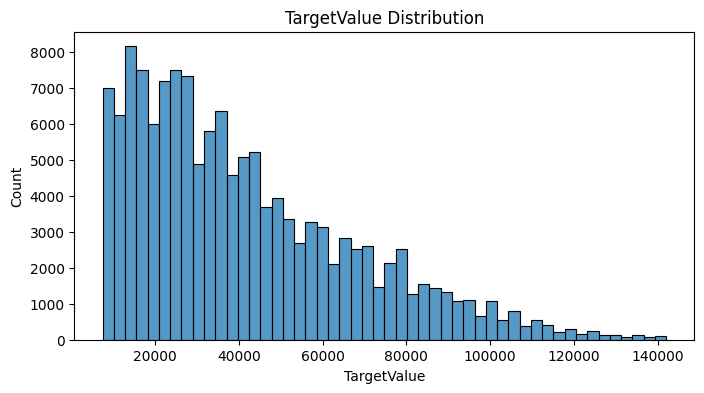

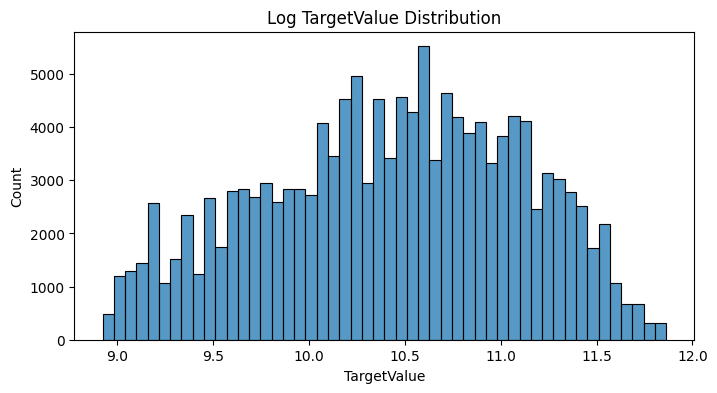

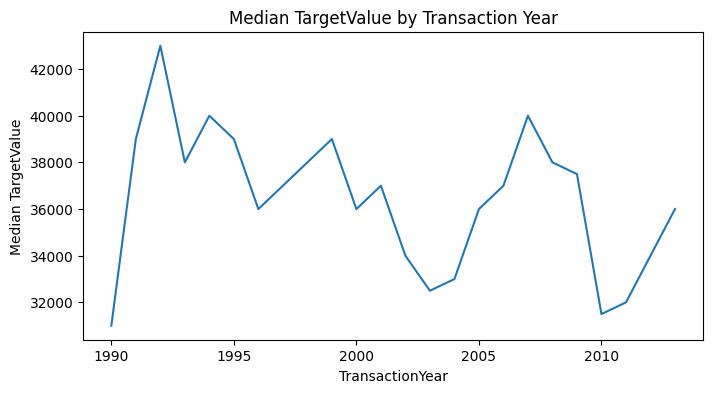

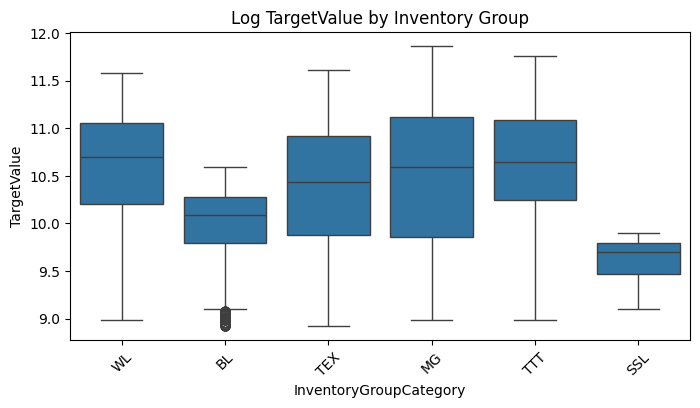

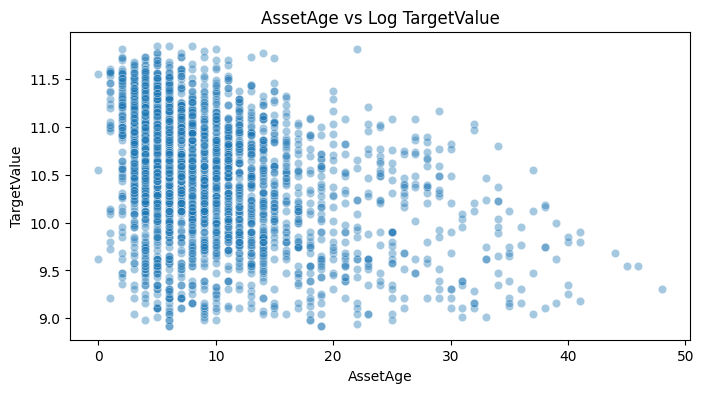

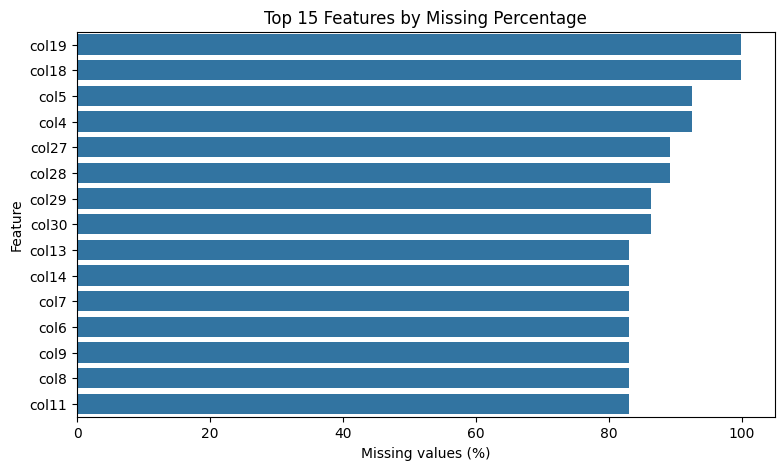

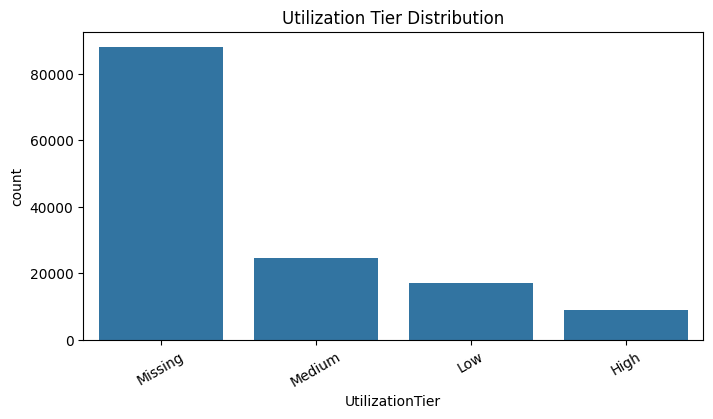

In [4]:
# EDA
train_eda = add_basic_features(train)

plt.figure(figsize=(8, 4))
sns.histplot(train[TARGET], bins=50)
plt.title("TargetValue Distribution")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(train[TARGET]), bins=50)
plt.title("Log TargetValue Distribution")
plt.show()

plt.figure(figsize=(8, 4))
train_eda.groupby("TransactionYear")[TARGET].median().plot()
plt.title("Median TargetValue by Transaction Year")
plt.ylabel("Median TargetValue")
plt.show()

plt.figure(figsize=(8, 4))
top_groups = train_eda["InventoryGroupCategory"].value_counts().head(10).index
group_mask = train_eda["InventoryGroupCategory"].isin(top_groups)
sns.boxplot(
    data=train_eda[group_mask],
    x="InventoryGroupCategory",
    y=np.log1p(train_eda.loc[group_mask, TARGET])
)
plt.xticks(rotation=45)
plt.title("Log TargetValue by Inventory Group")
plt.show()

plt.figure(figsize=(8, 4))
sample_plot = train_eda.sample(min(3000, len(train_eda)), random_state=42)
sns.scatterplot(
    data=sample_plot,
    x="AssetAge",
    y=np.log1p(sample_plot[TARGET]),
    alpha=0.4
)
plt.title("AssetAge vs Log TargetValue")
plt.show()

missing_pct = train.isna().mean().mul(100).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.title("Top 15 Features by Missing Percentage")
plt.show()

utilization_plot = train[["UtilizationTier"]].copy()
utilization_plot["UtilizationTier"] = utilization_plot["UtilizationTier"].fillna("Missing")
plt.figure(figsize=(8, 4))
sns.countplot(
    data=utilization_plot,
    x="UtilizationTier",
    order=utilization_plot["UtilizationTier"].value_counts().index
)
plt.title("Utilization Tier Distribution")
plt.xticks(rotation=30)
plt.show()

In [5]:
# Configuration
RANDOM_STATE = 42
VALID_SIZE = 0.20
N_FOLDS = 5

freq_cols = [
    "ProductConfigID",
    "Spec_FullDescriptor",
    "Spec_BaseClass",
    "Spec_SubClass",
    "VendorPartnerID",
    "RegionCode",
    "InventoryGroupCategory",
    "InventoryGroupDescription"
]

target_encode_cols = [
    "ProductConfigID",
    "Spec_FullDescriptor",
    "Spec_BaseClass",
    "Spec_SubClass",
    "RegionCode"
]

In [6]:
# Feature engineering helper functions for the model
def add_frequency_features(train_df, test_df, cols):
    train_df = train_df.copy()
    test_df = test_df.copy()

    for col in cols:
        if col not in train_df.columns:
            continue

        both = pd.concat(
            [safe_str(train_df[col]), safe_str(test_df[col])],
            axis=0
        )
        counts = both.value_counts(dropna=False)

        train_df[f"{col}_Frequency"] = (
            safe_str(train_df[col]).map(counts).astype("float32")
        )
        test_df[f"{col}_Frequency"] = (
            safe_str(test_df[col]).map(counts).astype("float32")
        )

    return train_df, test_df

def add_target_encoding(
    X_train,
    y_train,
    X_valid=None,
    X_test=None,
    cols=None,
    n_splits=5
):
    X_train = X_train.copy()
    X_valid = None if X_valid is None else X_valid.copy()
    X_test = None if X_test is None else X_test.copy()

    global_mean = y_train.mean()

    for col in cols:
        if col not in X_train.columns:
            continue

        new_col = f"{col}_TE"
        X_train[new_col] = np.nan
        train_categories = safe_str(X_train[col])

        inner_kf = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=RANDOM_STATE
        )

        for train_idx, valid_idx in inner_kf.split(X_train):
            category_means = (
                y_train.iloc[train_idx]
                .groupby(train_categories.iloc[train_idx])
                .mean()
            )
            X_train.loc[X_train.index[valid_idx], new_col] = (
                train_categories.iloc[valid_idx].map(category_means)
            )

        full_category_means = y_train.groupby(train_categories).mean()
        X_train[new_col] = X_train[new_col].fillna(global_mean).astype("float32")

        if X_valid is not None and col in X_valid.columns:
            X_valid[new_col] = (
                safe_str(X_valid[col])
                .map(full_category_means)
                .fillna(global_mean)
                .astype("float32")
            )

        if X_test is not None and col in X_test.columns:
            X_test[new_col] = (
                safe_str(X_test[col])
                .map(full_category_means)
                .fillna(global_mean)
                .astype("float32")
            )

    return X_train, X_valid, X_test

In [7]:
# Baseline and CatBoost data preparation
def make_sklearn_pipeline(X, model, scale_numeric=False):
    numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = [col for col in X.columns if col not in numeric_cols]

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_cols),
        ("categorical", categorical_pipeline, categorical_cols)
    ])

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

def prepare_catboost_frames(X_train, X_valid=None, X_test=None):
    X_train = X_train.copy()
    X_valid = None if X_valid is None else X_valid.copy()
    X_test = None if X_test is None else X_test.copy()

    categorical_cols = (
        X_train.select_dtypes(include=["object", "category", "string"])
        .columns
        .tolist()
    )

    # ProductConfigID is an identifier even when pandas reads it as numeric.
    if "ProductConfigID" in X_train.columns and "ProductConfigID" not in categorical_cols:
        categorical_cols.append("ProductConfigID")

    frames = [X_train]
    if X_valid is not None:
        frames.append(X_valid)
    if X_test is not None:
        frames.append(X_test)

    for frame in frames:
        for col in categorical_cols:
            frame[col] = safe_str(frame[col])

        numeric_cols = [col for col in frame.columns if col not in categorical_cols]
        frame[numeric_cols] = frame[numeric_cols].replace([np.inf, -np.inf], np.nan)

    return X_train, X_valid, X_test, categorical_cols

In [8]:
train_fe = add_basic_features(train)
test_fe = add_basic_features(test)

train_fe, test_fe = add_frequency_features(train_fe, test_fe, freq_cols)

test_ids = test_fe[ID_COLUMN].copy()

columns_to_drop = [TARGET, ID_COLUMN, "AssetID", "TransactionDate"]
X_base = train_fe.drop(columns=columns_to_drop, errors="ignore")
X_test_base = test_fe.drop(
    columns=[ID_COLUMN, "AssetID", "TransactionDate"],
    errors="ignore"
)

y_true = train[TARGET]
y_log = np.log1p(y_true)

print("Training shape:", X_base.shape)
print("Test shape:", X_test_base.shape)

Training shape: (138701, 67)
Test shape: (15000, 67)


In [9]:
# Holdout split used for baseline comparison and CatBoost tuning
train_indices, valid_indices = train_test_split(
    np.arange(len(X_base)),
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE
)

X_train = X_base.iloc[train_indices].copy()
X_valid = X_base.iloc[valid_indices].copy()

y_train_log = y_log.iloc[train_indices]
y_valid_log = y_log.iloc[valid_indices]
y_valid_true = y_true.iloc[valid_indices]

X_train_te, X_valid_te, _ = add_target_encoding(
    X_train,
    y_train_log,
    X_valid=X_valid,
    cols=target_encode_cols
)

X_train_cb, X_valid_cb, _, cat_cols = prepare_catboost_frames(
    X_train_te,
    X_valid_te
)

train_pool = Pool(X_train_cb, y_train_log, cat_features=cat_cols)
valid_pool = Pool(X_valid_cb, y_valid_log, cat_features=cat_cols)
print(f"CatBoost categorical features: {len(cat_cols)}")

CatBoost categorical features: 46


In [10]:
# Model configurations
baseline_models = {
    "Ridge Linear Model": make_sklearn_pipeline(
        X_train_te,
        Ridge(alpha=20),
        scale_numeric=True
    ),
    "Random Forest": make_sklearn_pipeline(
        X_train_te,
        RandomForestRegressor(
            n_estimators=80,
            max_depth=16,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        scale_numeric=False
    )
}

base_cat_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 50000,
    "learning_rate": 0.03,
    "depth": 8,
    "l2_leaf_reg": 5.0,
    "random_strength": 1.0,
    "bootstrap_type": "Bayesian",
    "bagging_temperature": 0.5,
    "border_count": 128,
    "max_ctr_complexity": 1,
    "random_seed": RANDOM_STATE,
    "task_type": "GPU",
    "devices": "0",
    "gpu_ram_part": 0.90,
    "allow_writing_files": False,
    "verbose": 200
}

tuning_configs = [
    # {
    #     "depth": 7,
    #     "learning_rate": 0.035,
    #     "l2_leaf_reg": 5.0,
    #     "random_strength": 0.5,
    #     "bagging_temperature": 0.5
    # },
    # {
    #     "depth": 8,
    #     "learning_rate": 0.03,
    #     "l2_leaf_reg": 8.0,
    #     "random_strength": 1.0,
    #     "bagging_temperature": 0.8
    # },
    {
        "depth": 9,
        "learning_rate": 0.025,
        "l2_leaf_reg": 10.0,
        "random_strength": 1.0,
        "bagging_temperature": 1.0
    }
]

In [11]:
# Baseline model training, followed by the GPU CatBoost baseline
baseline_results = []

for model_name, model in baseline_models.items():
    model.fit(X_train_te, y_train_log)
    predictions = np.expm1(model.predict(X_valid_te))
    score = rmsle(y_valid_true, predictions)
    baseline_results.append({
        "Model": model_name,
        "Validation_RMSLE": score
    })
    print(f"{model_name}: {score:.6f}")

results_df = pd.DataFrame(baseline_results)

cat_model = CatBoostRegressor(**base_cat_params)
cat_model.fit(
    train_pool,
    eval_set=valid_pool,
    early_stopping_rounds=300,
    use_best_model=True
)

cat_predictions = np.expm1(cat_model.predict(valid_pool))
cat_score = rmsle(y_valid_true, cat_predictions)
print(f"CatBoost GPU RMSLE: {cat_score:.6f}")

Ridge Linear Model: 0.296148
Random Forest: 0.217292
0:	learn: 0.6562835	test: 0.6543606	best: 0.6543606 (0)	total: 135ms	remaining: 1h 52m 53s
200:	learn: 0.2417323	test: 0.2405548	best: 0.2405548 (200)	total: 1.94s	remaining: 8m 1s
400:	learn: 0.2273545	test: 0.2279887	best: 0.2279887 (400)	total: 3.56s	remaining: 7m 20s
600:	learn: 0.2188952	test: 0.2212786	best: 0.2212786 (600)	total: 5.15s	remaining: 7m 3s
800:	learn: 0.2138015	test: 0.2178204	best: 0.2178204 (800)	total: 6.71s	remaining: 6m 52s
1000:	learn: 0.2096668	test: 0.2153126	best: 0.2153126 (1000)	total: 8.26s	remaining: 6m 44s
1200:	learn: 0.2063510	test: 0.2134841	best: 0.2134841 (1200)	total: 9.82s	remaining: 6m 38s
1400:	learn: 0.2034143	test: 0.2120334	best: 0.2120334 (1400)	total: 11.4s	remaining: 6m 35s
1600:	learn: 0.2007147	test: 0.2107597	best: 0.2107597 (1600)	total: 13s	remaining: 6m 31s
1800:	learn: 0.1983744	test: 0.2097379	best: 0.2097379 (1800)	total: 14.6s	remaining: 6m 29s
2000:	learn: 0.1960805	test: 0.

,Model,Validation_RMSLE
2,CatBoost GPU,0.196249
1,Random Forest,0.217292
0,Ridge Linear Model,0.296148


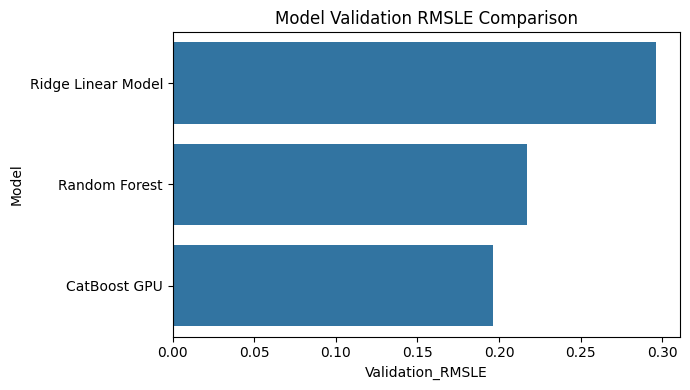

In [12]:
# Comparison of baseline models
results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([{
            "Model": "CatBoost GPU",
            "Validation_RMSLE": cat_score
        }])
    ],
    ignore_index=True
)
display(results_df.sort_values("Validation_RMSLE"))

plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x="Validation_RMSLE", y="Model")
plt.title("Model Validation RMSLE Comparison")
plt.tight_layout()
plt.show()

In [13]:
# Small GPU hyperparameter search on the holdout split
tuning_results = []

for config_number, config in enumerate(tuning_configs, start=1):
    params = {**base_cat_params, **config}
    tuning_model = CatBoostRegressor(**params)
    tuning_model.fit(
        train_pool,
        eval_set=valid_pool,
        early_stopping_rounds=300,
        use_best_model=True,
        verbose=False
    )

    predictions = np.expm1(tuning_model.predict(valid_pool))
    score = rmsle(y_valid_true, predictions)
    best_iteration = tuning_model.get_best_iteration() + 1

    tuning_results.append({
        "Config_No": config_number,
        "RMSLE": score,
        "Best_Iteration": best_iteration,
        "Params": config
    })
    print(
        f"Config {config_number}: RMSLE={score:.6f}, "
        f"iteration={best_iteration}"
    )
    del tuning_model
    gc.collect()

tuning_results_df = pd.DataFrame(tuning_results)
display(tuning_results_df.sort_values("RMSLE"))

best_row = tuning_results_df.sort_values("RMSLE").iloc[0]
best_config = best_row["Params"]
final_params = {**base_cat_params, **best_config, "iterations": 30000}

print("Selected parameters:")
print(best_config)

# Release fitted holdout models and pools before five-fold training.
del cat_model, train_pool, valid_pool, baseline_models
gc.collect()

Config 1: RMSLE=0.196724, iteration=23465


,Config_No,RMSLE,Best_Iteration,Params
0,1,0.196724,23465,"{'depth': 9, 'learning_rate': 0.025, 'l2_leaf_..."


Selected parameters:
{'depth': 9, 'learning_rate': 0.025, 'l2_leaf_reg': 10.0, 'random_strength': 1.0, 'bagging_temperature': 1.0}


2796

In [14]:
# MAIN TRAINING CELL: five CatBoost GPU folds
cross_validator = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

cat_oof_log = np.zeros(len(X_base))
cat_test_log = np.zeros(len(X_test_base))

best_iterations = []
fold_scores = []
fold_importances = []

for fold, (train_idx, valid_idx) in enumerate(
    cross_validator.split(X_base),
    start=1
):
    print(f"\nTraining fold {fold}/{N_FOLDS}")

    X_train_fold = X_base.iloc[train_idx].copy()
    X_valid_fold = X_base.iloc[valid_idx].copy()

    y_train_fold = y_log.iloc[train_idx]
    y_valid_fold_log = y_log.iloc[valid_idx]
    y_valid_fold_true = y_true.iloc[valid_idx]

    X_train_fold, X_valid_fold, X_test_fold = add_target_encoding(
        X_train_fold,
        y_train_fold,
        X_valid=X_valid_fold,
        X_test=X_test_base,
        cols=target_encode_cols
    )

    X_train_fold, X_valid_fold, X_test_fold, fold_cat_cols = (
        prepare_catboost_frames(
            X_train_fold,
            X_valid_fold,
            X_test_fold
        )
    )

    fold_train_pool = Pool(
        X_train_fold,
        y_train_fold,
        cat_features=fold_cat_cols
    )
    fold_valid_pool = Pool(
        X_valid_fold,
        y_valid_fold_log,
        cat_features=fold_cat_cols
    )
    fold_test_pool = Pool(X_test_fold, cat_features=fold_cat_cols)

    fold_model = CatBoostRegressor(**final_params)
    fold_model.fit(
        fold_train_pool,
        eval_set=fold_valid_pool,
        early_stopping_rounds=300,
        use_best_model=True
    )

    best_iteration = fold_model.get_best_iteration() + 1
    fold_valid_log = fold_model.predict(
        fold_valid_pool,
        ntree_end=best_iteration
    )
    fold_test_log = fold_model.predict(
        fold_test_pool,
        ntree_end=best_iteration
    )

    cat_oof_log[valid_idx] = fold_valid_log
    cat_test_log += fold_test_log / N_FOLDS

    fold_predictions = np.clip(np.expm1(fold_valid_log), 0, None)
    fold_score = rmsle(y_valid_fold_true, fold_predictions)

    fold_scores.append(fold_score)
    best_iterations.append(best_iteration)
    fold_importances.append(pd.Series(
        fold_model.get_feature_importance(),
        index=X_train_fold.columns
    ))

    print(f"Fold {fold} RMSLE: {fold_score:.6f}")

    del (
        fold_model,
        fold_train_pool,
        fold_valid_pool,
        fold_test_pool,
        X_train_fold,
        X_valid_fold,
        X_test_fold
    )
    gc.collect()

valid_predictions = np.clip(np.expm1(cat_oof_log), 0, None)
test_predictions = np.clip(np.expm1(cat_test_log), 0, None)


Training fold 1/5
0:	learn: 0.6584729	test: 0.6565435	best: 0.6565435 (0)	total: 22.6ms	remaining: 11m 16s
200:	learn: 0.2425806	test: 0.2416012	best: 0.2416012 (200)	total: 2.37s	remaining: 5m 51s
400:	learn: 0.2275949	test: 0.2286218	best: 0.2286218 (400)	total: 4.62s	remaining: 5m 40s
600:	learn: 0.2191851	test: 0.2222011	best: 0.2222011 (600)	total: 6.83s	remaining: 5m 34s
800:	learn: 0.2135315	test: 0.2183349	best: 0.2183349 (800)	total: 9.02s	remaining: 5m 28s
1000:	learn: 0.2089817	test: 0.2156077	best: 0.2156077 (1000)	total: 11.2s	remaining: 5m 25s
1200:	learn: 0.2054287	test: 0.2137197	best: 0.2137197 (1200)	total: 13.4s	remaining: 5m 21s
1400:	learn: 0.2024519	test: 0.2122868	best: 0.2122868 (1400)	total: 15.7s	remaining: 5m 19s
1600:	learn: 0.1999604	test: 0.2111901	best: 0.2111901 (1600)	total: 17.8s	remaining: 5m 15s
1800:	learn: 0.1974730	test: 0.2101223	best: 0.2101223 (1800)	total: 20s	remaining: 5m 12s
2000:	learn: 0.1952819	test: 0.2092639	best: 0.2092639 (2000)	tot

,Fold,RMSLE,Best_Iteration
0,1,0.197541,18896
1,2,0.198647,20567
2,3,0.198667,23885
3,4,0.199965,23203
4,5,0.198058,21204


Mean fold RMSLE: 0.198575
Overall OOF RMSLE: 0.198577
Average best iteration: 21551


,Feature,Importance
0,ProductConfigID_TE,16.578732
1,Spec_FullDescriptor_TE,13.150371
2,AssetAge,9.487573
3,TransactionDays,8.412020
4,ManufactureYear,7.683238
5,FunctionalClassification,3.632864
6,YearInventory,3.616464
7,TransactionDayOfYear,2.379502
8,Spec_BaseClass_Frequency,2.250397
9,Spec_BaseClass_TE,2.241352


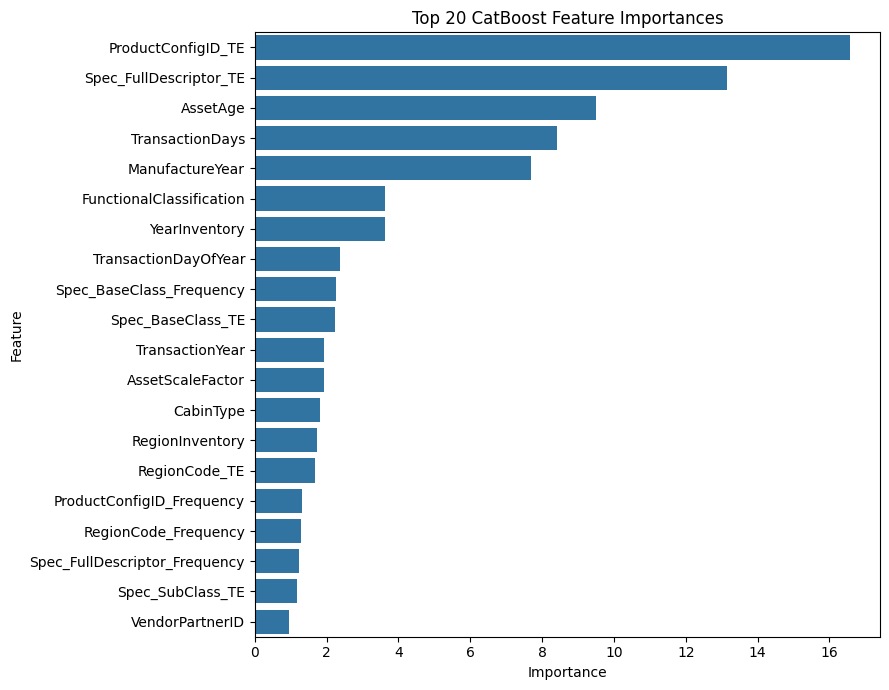

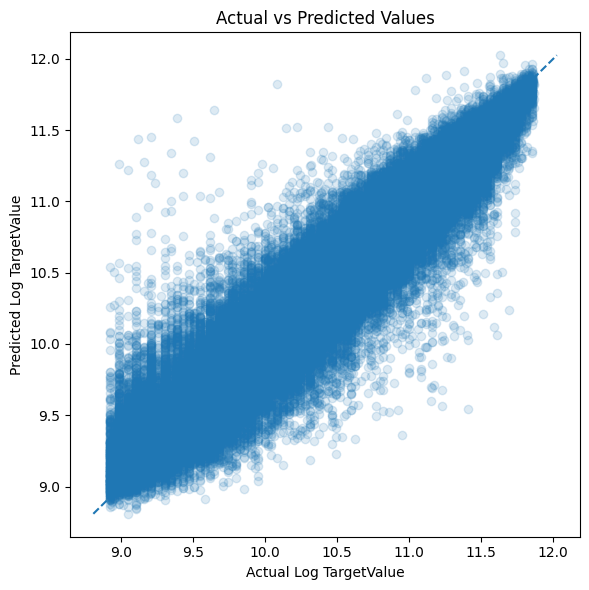

,TargetValue,InventoryGroupCategory,UtilizationTier,TransactionYear,HasOperationalHours,Prediction,AbsoluteLogError
41946,9100.0,TTT,NaN,2000,0,92473.569195,2.318549
30470,8000.0,TEX,NaN,2008,0,77999.137416,2.277144
21266,10000.0,TEX,NaN,2005,0,94088.071425,2.241557
30067,12000.0,TEX,NaN,2000,0,107586.249246,2.193312
79081,8500.0,WL,NaN,2010,1,74393.797627,2.169202
37385,9500.0,WL,NaN,2000,0,78650.662790,2.113632
23533,15500.0,TTT,NaN,1996,0,113676.982535,1.992465
71328,11500.0,TEX,Medium,1996,1,83747.224205,1.985381
30770,10000.0,TEX,NaN,1999,0,71781.003380,1.970949
72037,13500.0,TEX,NaN,2001,0,91465.721158,1.913211


In [15]:
# POST TRAINING ANALYSIS CELL
fold_results = pd.DataFrame({
    "Fold": np.arange(1, len(fold_scores) + 1),
    "RMSLE": fold_scores,
    "Best_Iteration": best_iterations
})

cv_score = rmsle(y_true, valid_predictions)
display(fold_results)
print(f"Mean fold RMSLE: {np.mean(fold_scores):.6f}")
print(f"Overall OOF RMSLE: {cv_score:.6f}")
print(f"Average best iteration: {int(np.mean(best_iterations))}")

importance_df = (
    pd.concat(fold_importances, axis=1)
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(20)
    .rename_axis("Feature")
    .reset_index(name="Importance")
)
display(importance_df)

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Top 20 CatBoost Feature Importances")
plt.tight_layout()
plt.show()

actual_log = np.log1p(y_true)
predicted_log = np.log1p(valid_predictions)
minimum = min(actual_log.min(), predicted_log.min())
maximum = max(actual_log.max(), predicted_log.max())

plt.figure(figsize=(6, 6))
plt.scatter(actual_log, predicted_log, alpha=0.15)
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Actual Log TargetValue")
plt.ylabel("Predicted Log TargetValue")
plt.title("Actual vs Predicted Values")
plt.tight_layout()
plt.show()

analysis_columns = [
    TARGET,
    "InventoryGroupCategory",
    "UtilizationTier",
    "TransactionYear",
    "HasOperationalHours"
]
available_analysis_columns = [
    col for col in analysis_columns if col in train_fe.columns
]
error_df = train_fe[available_analysis_columns].copy()
error_df["Prediction"] = valid_predictions
error_df["AbsoluteLogError"] = np.abs(
    np.log1p(error_df[TARGET]) - np.log1p(error_df["Prediction"])
)
worst_predictions = error_df.sort_values(
    "AbsoluteLogError",
    ascending=False
).head(10)
display(worst_predictions)

## submission[ID_COLUMN] = test_ids
submission[TARGET] = test_predictions

submission.to_csv("submission.csv", index=False)

print("Created submission.csv")
display(submission.head())